# NYC Subway Complaints EDA

This is an exploratory data analysis of historic NYPD complaint data where we'll be looking at crimes that were reported on the subway.

The [NYPD Complaint Data Historic](https://data.cityofnewyork.us/Public-Safety/NYPD-Complaint-Data-Historic/qgea-i56i/) dataset is free to download from the [NYC Open Data](https://opendata.cityofnewyork.us/) website.

This dataset includes all valid felony, misdemeanor, and violation crimes reported to the New York City Police Department (NYPD) from 2006 to the end of last year (2025). For the purposes of this analysis, we will look at crimes between 2018 - 2025.

## Notebook Configuration

### Install Packages

In [102]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import os
import requests

### Configure Pandas

In [103]:
# set Pandas display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

### Configure Plots

In [104]:
sns.set_style("whitegrid")  # whitegrid
# sns.set_theme(context='notebook', style='whitegrid', palette='tab10', font=font_name, rc={"figure.dpi": 96})
plt.rcParams['figure.frameon'] = True
plt.rcParams['figure.dpi'] = 96
plt.rcParams['figure.facecolor'] ='#fafafa'
colors = plt.color_sequences['tab20c']

### Install Poppins Font

In [105]:
POPPINS_LIGHT_FONT_GITHUB_URL = "https://github.com/google/fonts/blob/main/ofl/poppins/Poppins-Light.ttf?raw=true"
POPPINS_REGULAR_FONT_GITHUB_URL = "https://github.com/google/fonts/blob/main/ofl/poppins/Poppins-Regular.ttf?raw=true"
POPPINS_BOLD_FONT_GITHUB_URL = "https://github.com/google/fonts/blob/main/ofl/poppins/Poppins-Bold.ttf?raw=true"

In [106]:
POPPINS_LIGHT_FONT_PATH = "../data/Poppins-Light.ttf"
POPPINS_REGULAR_FONT_PATH = "../data/Poppins-Regular.ttf"
POPPINS_BOLD_FONT_PATH = "../data/Poppins-Bold.ttf.ttf"

In [107]:
for font_url, font_path in [
    (POPPINS_LIGHT_FONT_GITHUB_URL, POPPINS_LIGHT_FONT_PATH),
    (POPPINS_REGULAR_FONT_GITHUB_URL, POPPINS_REGULAR_FONT_PATH),
    (POPPINS_BOLD_FONT_GITHUB_URL, POPPINS_BOLD_FONT_PATH)
]:

    if not os.path.exists(font_path):
        print(f"Downloading Inter Variable font from: {font_url}")
        os.makedirs("../data", exist_ok=True)

        try:
            # request the font from url
            with requests.get(font_url, stream=True) as response:
                # check if the request was successful
                response.raise_for_status()
                # write the data to the file
                with open(font_path, 'wb') as f:
                    f.write(response.content)
                print("Inter font downloaded successfully!")
        except requests.exceptions.RequestException as e:
            print(f"An error occurred requesting the font: {e}")

    else:
        print(f"Found a local copy of {font_path.split("/")[-1]} font, skipping download.")

Found a local copy of Poppins-Light.ttf font, skipping download.
Found a local copy of Poppins-Regular.ttf font, skipping download.
Found a local copy of Poppins-Bold.ttf.ttf font, skipping download.


In [108]:
loaded_fonts = []
for font_path in [POPPINS_LIGHT_FONT_PATH, POPPINS_REGULAR_FONT_PATH, POPPINS_BOLD_FONT_PATH]:
    if os.path.exists(font_path):
        fm.fontManager.addfont(font_path)
        font_prop = fm.FontProperties(fname=font_path)
        font_name = font_prop.get_name()
        loaded_fonts.append(font_name)

if loaded_fonts:
    plt.rcParams['font.family'] = ["Poppins"]
    plt.rcParams['font.sans-serif'] = loaded_fonts

    print("Font loaded successfully.")

Font loaded successfully.


## Load and Prepare data

In [109]:
OPEN_DATA_CSV_PATH = "../data/NYPD_Complaint_Data_Historic_20260505.csv"

In [110]:
# check if the 'data' directory exists, if not create it
if not os.path.exists('../data'):
    os.makedirs('../data', exist_ok=True)
# check if the 'data/complaints.csv' file exists, if not prompt the user to download it
if not os.path.exists(OPEN_DATA_CSV_PATH):
    print("Please download the complaints.csv file from the NYC Open Data portal and place it in the 'data' directory.")
else:
    print(f"{OPEN_DATA_CSV_PATH.split("/")[-1]} file found.")

NYPD_Complaint_Data_Historic_20260505.csv file found.


In [111]:
df = pd.read_csv(OPEN_DATA_CSV_PATH, parse_dates=["CMPLNT_FR_DT"], low_memory=False)

In [112]:
df.info(show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 4013797 entries, 0 to 4013796
Data columns (total 35 columns):
 #   Column             Non-Null Count    Dtype         
---  ------             --------------    -----         
 0   CMPLNT_NUM         4013797 non-null  str           
 1   CMPLNT_FR_DT       4013797 non-null  datetime64[us]
 2   CMPLNT_FR_TM       4013797 non-null  str           
 3   CMPLNT_TO_DT       3684322 non-null  str           
 4   CMPLNT_TO_TM       4013797 non-null  str           
 5   ADDR_PCT_CD        4013700 non-null  float64       
 6   RPT_DT             4013797 non-null  str           
 7   KY_CD              4013797 non-null  int64         
 8   OFNS_DESC          4013797 non-null  str           
 9   PD_CD              4010804 non-null  float64       
 10  PD_DESC            4013797 non-null  str           
 11  CRM_ATPT_CPTD_CD   4013797 non-null  str           
 12  LAW_CAT_CD         4013797 non-null  str           
 13  BORO_NM            4013797 non-null  s

### Duplicates

In [113]:
# check for duplicate rows by CMPLNT_NUM and drop duplicates if found
duplicate_count = df.duplicated(subset=['CMPLNT_NUM']).sum()
print(f"Number of duplicate rows based on CMPLNT_NUM: {duplicate_count}")
if duplicate_count > 0:
    df = df.drop_duplicates(subset=['CMPLNT_NUM'])
    print(f"Dropped {duplicate_count} duplicate rows based on CMPLNT_NUM.")

Number of duplicate rows based on CMPLNT_NUM: 2
Dropped 2 duplicate rows based on CMPLNT_NUM.


### Date features

In [114]:
# confirm that the date range is from 2018 - 2025
print(f"Date range: {df['CMPLNT_FR_DT'].min()} to {df['CMPLNT_FR_DT'].max()}")

Date range: 2018-01-01 00:00:00 to 2025-12-31 00:00:00


In [115]:
df['CMPLNT_FR_YEAR'] = df['CMPLNT_FR_DT'].dt.year
df['CMPLNT_FR_MONTH'] = df['CMPLNT_FR_DT'].dt.month
df['CMPLNT_FR_DAY'] = df['CMPLNT_FR_DT'].dt.day 
df['CMPLNT_FR_DAYOFWEEK'] = df['CMPLNT_FR_DT'].dt.day_name()

### Preview the data

In [116]:
df.head()

,CMPLNT_NUM,CMPLNT_FR_DT,CMPLNT_FR_TM,CMPLNT_TO_DT,CMPLNT_TO_TM,ADDR_PCT_CD,RPT_DT,KY_CD,OFNS_DESC,PD_CD,PD_DESC,CRM_ATPT_CPTD_CD,LAW_CAT_CD,BORO_NM,LOC_OF_OCCUR_DESC,PREM_TYP_DESC,JURIS_DESC,JURISDICTION_CODE,PARKS_NM,HADEVELOPT,HOUSING_PSA,X_COORD_CD,Y_COORD_CD,SUSP_AGE_GROUP,SUSP_RACE,SUSP_SEX,TRANSIT_DISTRICT,Latitude,Longitude,Lat_Lon,PATROL_BORO,STATION_NAME,VIC_AGE_GROUP,VIC_RACE,VIC_SEX,CMPLNT_FR_YEAR,CMPLNT_FR_MONTH,CMPLNT_FR_DAY,CMPLNT_FR_DAYOFWEEK
0,318206301,2025-12-31,20:00:00,12/31/2025,20:40:00,50.0,12/31/2025,341,PETIT LARCENY,333.0,"LARCENY,PETIT FROM STORE-SHOPL",COMPLETED,MISDEMEANOR,BRONX,INSIDE,CHAIN STORE,N.Y. POLICE DEPT,0,(null),(null),(null),"1,012,824","271,127",UNKNOWN,BLACK,M,NaN,40.910818,-73.896621,"(40.910818, -73.896621)",PATROL BORO BRONX,(null),UNKNOWN,UNKNOWN,D,2025,12,31,Wednesday
1,318196619,2025-12-30,19:00:00,12/30/2025,20:00:00,47.0,12/31/2025,126,MISCELLANEOUS PENAL LAW,198.0,CRIMINAL CONTEMPT 1,COMPLETED,FELONY,BRONX,(null),RESIDENCE-HOUSE,N.Y. POLICE DEPT,0,(null),(null),(null),"1,025,454","268,214",65+,AMERICAN INDIAN/ALASKAN NATIVE,M,NaN,40.902772,-73.850946,"(40.902772, -73.850946)",PATROL BORO BRONX,(null),<18,WHITE,M,2025,12,30,Tuesday
2,318194616,2025-12-31,12:30:00,NaN,(null),47.0,12/31/2025,344,ASSAULT 3 & RELATED OFFENSES,113.0,"MENACING,UNCLASSIFIED",COMPLETED,MISDEMEANOR,BRONX,INSIDE,HOMELESS SHELTER,N.Y. POLICE DEPT,0,(null),(null),(null),"1,024,875","269,317",<18,WHITE HISPANIC,F,NaN,40.905803,-73.853032,"(40.905803, -73.853032)",PATROL BORO BRONX,(null),25-44,WHITE HISPANIC,M,2025,12,31,Wednesday
3,318206286,2025-12-31,19:15:00,NaN,(null),47.0,12/31/2025,361,OFF. AGNST PUB ORD SENSBLTY &,639.0,AGGRAVATED HARASSMENT 2,COMPLETED,MISDEMEANOR,BRONX,INSIDE,RESIDENCE - APT. HOUSE,N.Y. POLICE DEPT,0,(null),(null),(null),"1,024,326","265,010",25-44,BLACK,M,NaN,40.893985,-73.855046,"(40.893985, -73.855046)",PATROL BORO BRONX,(null),45-64,BLACK,F,2025,12,31,Wednesday
4,318179017,2025-12-31,00:52:00,12/31/2025,01:18:00,47.0,12/31/2025,344,ASSAULT 3 & RELATED OFFENSES,101.0,ASSAULT 3,COMPLETED,MISDEMEANOR,BRONX,INSIDE,RESIDENCE - APT. HOUSE,N.Y. POLICE DEPT,0,(null),(null),(null),"1,023,593","261,233",<18,BLACK,F,NaN,40.883621,-73.857720,"(40.883621, -73.85772)",PATROL BORO BRONX,(null),<18,BLACK,M,2025,12,31,Wednesday


### Categorical data

In [117]:
# convert LAW_CAT_CD to ordered categorical type
law_cat_order = ['FELONY', 'MISDEMEANOR', 'VIOLATION']
# convert values to title case
df['LAW_CAT_CD'] = df['LAW_CAT_CD'].str.title()
df['LAW_CAT_CD'] = pd.Categorical(df['LAW_CAT_CD'], categories=[x.title() for x in law_cat_order], ordered=True)

### Clean and transform

In [118]:
# convert PREM_TYP_DESC to title case, keeping 'NYC' in uppercase
df['PREM_TYP_DESC'] = df['PREM_TYP_DESC'].str.title()   
df['PREM_TYP_DESC'] = df['PREM_TYP_DESC'].str.replace('Nyc', 'NYC', case=True)


In [119]:
# convert BORO_NM to title case
df['BORO_NM'] = df['BORO_NM'].str.title()

In [127]:
# convert OFNS_DESC to title case
df['OFNS_DESC'] = df['OFNS_DESC'].str.title()
# replace string values in OFNS_DESC 
replacement_dict = {
    'Criminal Mischief & Related Of': 'Criminal Mischief & Related Offenses',
    'Disruption Of A Religious Serv': 'Disruption Of A Religious Service',
    'Intoxicated/Impaired Driving': 'Intoxicated & Impaired Driving',
    'Kidnapping And Related Offenses': 'Kidnapping & Related Offenses',
    'Other Offenses Related To Thef': 'Other Offenses Related To Theft',
    # 'Other State Laws (Non Penal La': 'Other State Laws (Non Penal Law)',
}
replacement = {rf'\b{k}\b': v for k, v in replacement_dict.items()}

df['OFNS_DESC'] = df['OFNS_DESC'].str.replace(replacement, regex=True)


In [128]:
sorted(df['OFNS_DESC'].unique())

['(Null)',
 'Abortion',
 'Administrative Code',
 'Agriculture & Mrkts Law-Unclassified',
 'Alcoholic Beverage Control Law',
 'Anticipatory Offenses',
 'Arson',
 'Assault 3 & Related Offenses',
 "Burglar'S Tools",
 'Burglary',
 'Cannabis Related Offenses',
 'Child Abandonment/Non Support',
 'Child Abandonment/Non Support 1',
 'Criminal Mischief & Related Offenses',
 'Criminal Trespass',
 'Dangerous Drugs',
 'Dangerous Weapons',
 'Disorderly Conduct',
 'Disruption Of A Religious Service',
 'Endan Welfare Incomp',
 'Escape 3',
 'Felony Assault',
 'Felony Sex Crimes',
 'Forgery',
 'Fortune Telling',
 'Frauds',
 'Fraudulent Accosting',
 'Gambling',
 'Grand Larceny',
 'Grand Larceny Of Motor Vehicle',
 'Harrassment 2',
 'Homicide-Negligent,Unclassifie',
 'Homicide-Negligent-Vehicle',
 'Intoxicated & Impaired Driving',
 'Jostling',
 'Kidnapping',
 'Kidnapping & Related Offenses',
 'Loitering',
 'Loitering/Gambling (Cards, Dic',
 'Miscellaneous Penal Law',
 'Murder & Non-Negl. Manslaughter',
 

## Analysis

### Premises

Let's start by looking at the `PREM_TYP_DESC` column, which tells us the specific description of the premises; grocery store, residence, street, etc. We'll find that there is a category here specifically for the NYC subway.

In [129]:
# count the number of unique values in the 'PREM_TYP_DESC' column
unique_prem_types = df['PREM_TYP_DESC'].nunique()
print(f"Number of unique values in 'PREM_TYP_DESC': {unique_prem_types}")

Number of unique values in 'PREM_TYP_DESC': 89


In [130]:
# display the top 25 most common values in the 'PREM_TYP_DESC' column
prem_type_counts = df['PREM_TYP_DESC'].value_counts(normalize=True)
prem_type_counts.head(25).reset_index()

,PREM_TYP_DESC,proportion
0,Street,0.290529
1,Residence - Apt. House,0.221064
2,Residence-House,0.093916
3,Residence - Public Housing,0.066836
4,Chain Store,0.046006
5,Transit - NYC Subway,0.031040
6,Department Store,0.023390
7,Commercial Building,0.022398
8,Other,0.022229
9,Drug Store,0.018576


In [131]:
# note the percentage of complaints that have 'TRANSIT - NYC SUBWAY' in the 'PREM_TYP_DESC' column and it's rank among all complaint types
subway_complaints_percentage = prem_type_counts['Transit - NYC Subway'].sum() * 100
subway_complaints_rank = prem_type_counts.rank(ascending=False).loc['Transit - NYC Subway'] 
print(f"Percentage of complaints that are 'TRANSIT - NYC SUBWAY': {subway_complaints_percentage:.2f}%")
print(f"Rank of 'TRANSIT - NYC SUBWAY' complaints among all complaint types: {subway_complaints_rank}")


Percentage of complaints that are 'TRANSIT - NYC SUBWAY': 3.10%
Rank of 'TRANSIT - NYC SUBWAY' complaints among all complaint types: 6.0


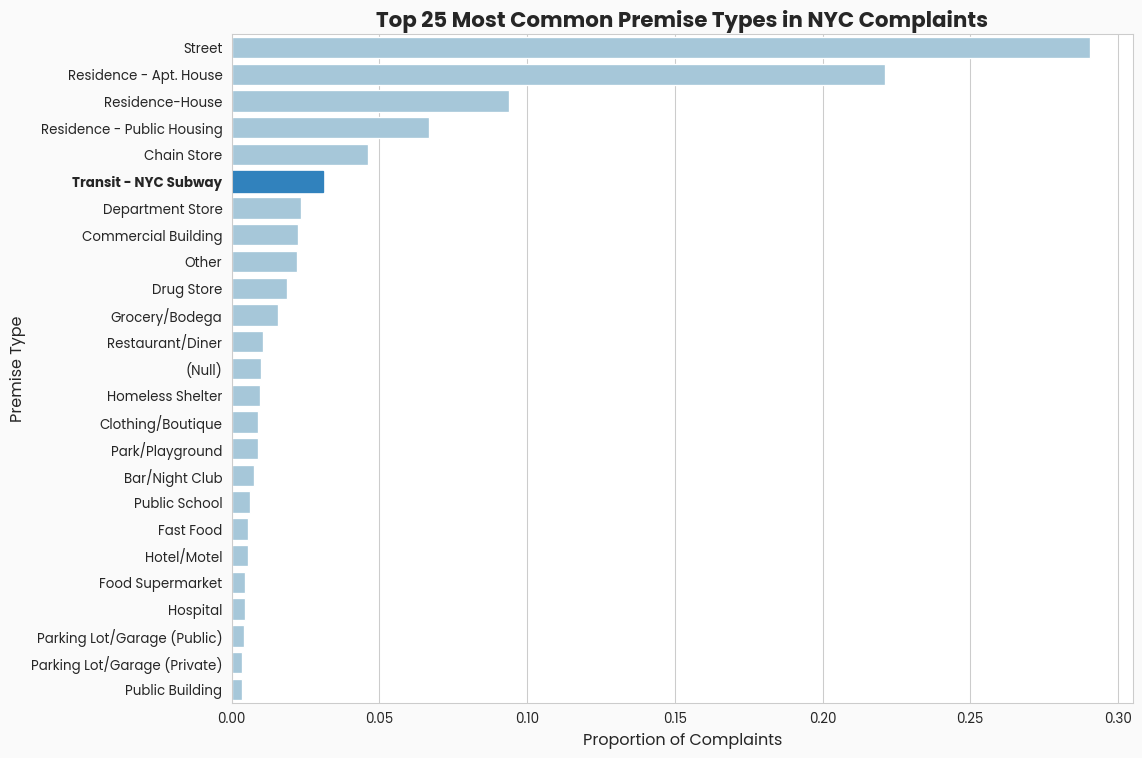

In [132]:
# Plot the distribution of the top 25 most common premise types
top_25_prem_types = prem_type_counts.head(25).reset_index()
# display(top_25_prem_types)
# top_25_prem_types.plot(kind='bar', figsize=(12, 8), color=colors[:25])
plt.figure(figsize=(12, 8))
sns.barplot(data=top_25_prem_types, x='proportion', y='PREM_TYP_DESC', color=colors[2])
# point out the 'TRANSIT - NYC SUBWAY' bar on the plot by bolding the label and changing the color of the bar to a different color
# get the index of the 'TRANSIT - NYC SUBWAY' bar
subway_index = top_25_prem_types[top_25_prem_types['PREM_TYP_DESC'] == 'Transit - NYC Subway'].index[0]
# bold the label of the 'TRANSIT - NYC SUBWAY' bar
plt.gca().get_yticklabels()[subway_index].set_fontweight('bold')
# change the color of the 'TRANSIT - NYC SUBWAY' bar to a different color
plt.gca().patches[subway_index].set_color(colors[0])
        
plt.title('Top 25 Most Common Premise Types in NYC Complaints', fontsize=16, fontweight='bold')
plt.xlabel('Proportion of Complaints', fontsize=12)
plt.ylabel('Premise Type', fontsize=12)
plt.tight_layout()
plt.show()  

### Transit - NYC Subway

In [133]:
transit_subway_complaints = df[df['PREM_TYP_DESC'] == 'Transit - NYC Subway']
transit_subway_complaints.head()

,CMPLNT_NUM,CMPLNT_FR_DT,CMPLNT_FR_TM,CMPLNT_TO_DT,CMPLNT_TO_TM,ADDR_PCT_CD,RPT_DT,KY_CD,OFNS_DESC,PD_CD,PD_DESC,CRM_ATPT_CPTD_CD,LAW_CAT_CD,BORO_NM,LOC_OF_OCCUR_DESC,PREM_TYP_DESC,JURIS_DESC,JURISDICTION_CODE,PARKS_NM,HADEVELOPT,HOUSING_PSA,X_COORD_CD,Y_COORD_CD,SUSP_AGE_GROUP,SUSP_RACE,SUSP_SEX,TRANSIT_DISTRICT,Latitude,Longitude,Lat_Lon,PATROL_BORO,STATION_NAME,VIC_AGE_GROUP,VIC_RACE,VIC_SEX,CMPLNT_FR_YEAR,CMPLNT_FR_MONTH,CMPLNT_FR_DAY,CMPLNT_FR_DAYOFWEEK
147,318178369,2025-12-31,02:24:00,12/31/2025,02:29:00,41.0,12/31/2025,235,Dangerous Drugs,511.0,"CONTROLLED SUBSTANCE, POSSESSI",COMPLETED,Misdemeanor,Bronx,(null),Transit - NYC Subway,N.Y. TRANSIT POLICE,1,(null),(null),(null),"1,014,509","238,113",18-24,WHITE HISPANIC,M,12.0,40.820189,-73.890675,"(40.82018895, -73.89067524)",PATROL BORO BRONX,HUNTS POINT AVENUE,UNKNOWN,UNKNOWN,E,2025,12,31,Wednesday
268,318185319,2025-12-31,09:40:00,12/31/2025,09:47:00,44.0,12/31/2025,343,Other Offenses Related To Theft,478.0,"THEFT OF SERVICES, UNCLASSIFIE",COMPLETED,Misdemeanor,Bronx,(null),Transit - NYC Subway,N.Y. TRANSIT POLICE,1,(null),(null),(null),"1,008,110","244,858",25-44,BLACK,M,11.0,40.838722,-73.913771,"(40.83872163, -73.91377061)",PATROL BORO BRONX,170 STREET,UNKNOWN,UNKNOWN,E,2025,12,31,Wednesday
331,318178745,2025-12-31,02:30:00,12/31/2025,03:00:00,14.0,12/31/2025,109,Grand Larceny,408.0,"LARCENY,GRAND FROM PERSON,LUSH WORKER(SLEEPING/UNCON VICTIM)",COMPLETED,Felony,Manhattan,(null),Transit - NYC Subway,N.Y. TRANSIT POLICE,1,(null),(null),(null),"990,886","213,048",UNKNOWN,UNKNOWN,U,4.0,40.751442,-73.976049,"(40.75144155, -73.9760491)",PATROL BORO MAN SOUTH,42 ST.-GRAND CENTRAL,18-24,WHITE HISPANIC,M,2025,12,31,Wednesday
369,318204934,2025-12-31,19:39:00,12/31/2025,19:41:00,14.0,12/31/2025,359,Offenses Against Public Admini,759.0,"PUBLIC ADMINISTATION,UNCLASS M",COMPLETED,Misdemeanor,Manhattan,(null),Transit - NYC Subway,N.Y. TRANSIT POLICE,1,(null),(null),(null),"985,764","213,806",25-44,BLACK,F,1.0,40.753533,-73.994537,"(40.7535327012632, -73.9945368920152)",PATROL BORO MAN SOUTH,42 ST.-TIMES SQUARE,UNKNOWN,UNKNOWN,E,2025,12,31,Wednesday
435,318179003,2025-12-31,01:40:00,12/31/2025,01:44:00,18.0,12/31/2025,344,Assault 3 & Related Offenses,101.0,ASSAULT 3,COMPLETED,Misdemeanor,Manhattan,(null),Transit - NYC Subway,N.Y. TRANSIT POLICE,1,(null),(null),(null),"988,099","217,000",UNKNOWN,UNKNOWN,M,1.0,40.762290,-73.986106,"(40.76229044, -73.98610578)",PATROL BORO MAN SOUTH,50 STREET,45-64,WHITE HISPANIC,M,2025,12,31,Wednesday


In [134]:
# count the number of complaints by year for 'TRANSIT - NYC SUBWAY' complaints
transit_subway_yearly_counts = transit_subway_complaints.groupby('CMPLNT_FR_YEAR').size() 
transit_subway_yearly_counts.reset_index(name='count')

,CMPLNT_FR_YEAR,count
0,2018,11948
1,2019,11884
2,2020,7170
3,2021,8756
4,2022,11134
5,2023,14142
6,2024,25864
7,2025,33691


In [135]:
percent_change_transit_subway_yearly_counts_2019_2025 = transit_subway_yearly_counts[2025] / transit_subway_yearly_counts[2019] * 100
print(f"The total number of all subway related complaints has risen nearly 3x from 2019 to 2025, with a {percent_change_transit_subway_yearly_counts_2019_2025:.2f}% increase in complaints over that time period.")

The total number of all subway related complaints has risen nearly 3x from 2019 to 2025, with a 283.50% increase in complaints over that time period.


In [136]:
print(f"Compared to pre-pandemic levels in 2019, the number of subway related complaints in 2025 has increased by {percent_change_transit_subway_yearly_counts_2019_2025:.2f}%.")

Compared to pre-pandemic levels in 2019, the number of subway related complaints in 2025 has increased by 283.50%.


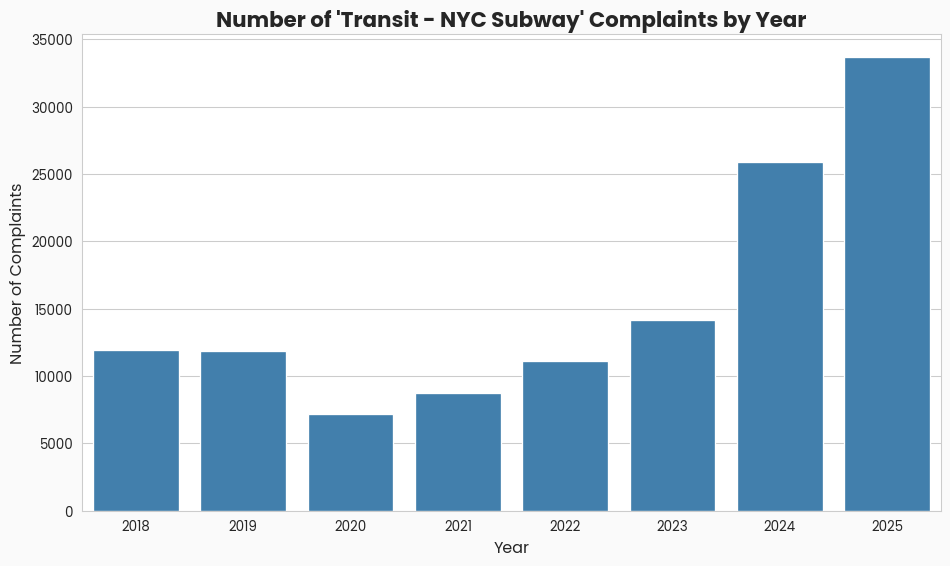

In [137]:
plt.figure(figsize=(10, 6))
sns.barplot(data=transit_subway_yearly_counts.reset_index(name='count'), x='CMPLNT_FR_YEAR', y='count', color=colors[0])
plt.title("Number of 'Transit - NYC Subway' Complaints by Year", fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Complaints', fontsize=12)     
plt.tight_layout()
plt.show()  

#### Level of Offense

In [138]:
transit_subway_yearly_counts_by_offense = transit_subway_complaints.groupby(['CMPLNT_FR_YEAR', 'LAW_CAT_CD']).size()
transit_subway_yearly_counts_by_offense.to_frame(name='count')

count
CMPLNT_FR_YEAR LAW_CAT_CD        
2018           Felony        5548
               Misdemeanor   5245
               Violation     1155
2019           Felony        5229
               Misdemeanor   5320
               Violation     1335
2020           Felony        2999
               Misdemeanor   3199
               Violation      972
2021           Felony        3196
               Misdemeanor   4481
               Violation     1079
2022           Felony        4095
               Misdemeanor   5508
               Violation     1531
2023           Felony        4640
               Misdemeanor   7405
               Violation     2097
2024           Felony        4954
               Misdemeanor  18030
               Violation     2880
2025           Felony        4958
               Misdemeanor  23407
               Violation     5326

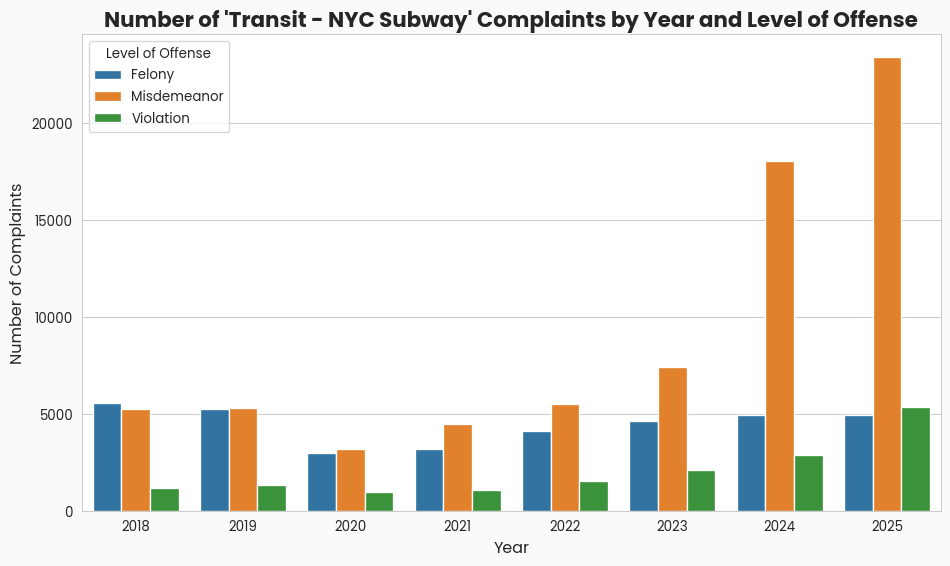

In [139]:
plt.figure(figsize=(10, 6))
sns.barplot(data=transit_subway_yearly_counts_by_offense.reset_index(name='count'), x='CMPLNT_FR_YEAR', hue="LAW_CAT_CD", y='count', palette='tab10')
plt.title("Number of 'Transit - NYC Subway' Complaints by Year and Level of Offense", fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Complaints', fontsize=12)
plt.legend(title='Level of Offense')         
plt.tight_layout()
plt.show()  

On the subway, misdemeanor crimes and violations have climbed to record numbers since 2023, while felony offenses have remained at normal levels.

#### Borough

In [140]:
transit_subway_yearly_counts_by_boro = transit_subway_complaints[transit_subway_complaints['BORO_NM'] != "(Null)"].groupby(['CMPLNT_FR_YEAR', 'BORO_NM']).size()
transit_subway_yearly_counts_by_boro.to_frame(name='count')

count
CMPLNT_FR_YEAR BORO_NM         
2018           Bronx       1918
               Brooklyn    2940
               Manhattan   5951
               Queens      1136
2019           Bronx       1894
               Brooklyn    3095
               Manhattan   5769
               Queens      1120
2020           Bronx       1200
               Brooklyn    1871
               Manhattan   3283
               Queens       799
2021           Bronx       1465
               Brooklyn    2116
               Manhattan   4075
               Queens      1070
2022           Bronx       1607
               Brooklyn    3229
               Manhattan   4833
               Queens      1403
2023           Bronx       2366
               Brooklyn    4497
               Manhattan   5399
               Queens      1850
2024           Bronx       5465
               Brooklyn    8010
               Manhattan   9179
               Queens      3190
2025           Bronx       6284
               Brooklyn   12056
               Manhattan  11334
               Queens      4013

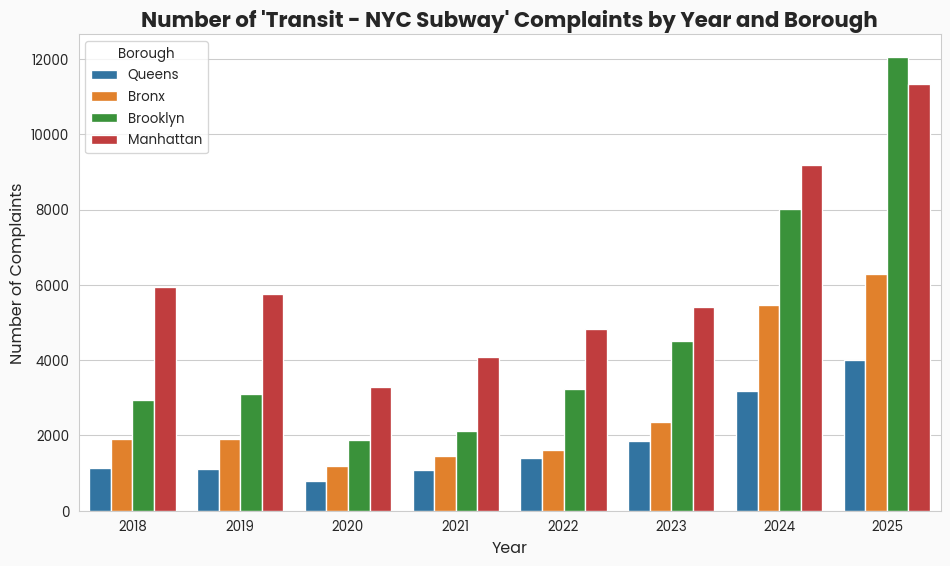

In [141]:
plt.figure(figsize=(10, 6))
sns.barplot(data=transit_subway_yearly_counts_by_boro.reset_index(name='count'), x='CMPLNT_FR_YEAR', hue="BORO_NM", y='count', palette='tab10', hue_order=['Queens', 'Bronx', 'Brooklyn', 'Manhattan'])
plt.title("Number of 'Transit - NYC Subway' Complaints by Year and Borough", fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Complaints', fontsize=12) 
plt.legend(title='Borough') 
plt.tight_layout()
plt.show()  

In 2024 and 2025 the number of 'Transit - NYC Subway' complaints was higher than usual in all boroughs, Brooklyn overtook Manhattan with the highest number of complaints in 2025.

#### Offense Descripton

In [142]:
offense_description_counts_by_law_cat = transit_subway_complaints.groupby(['LAW_CAT_CD', 'OFNS_DESC']).size()
offense_description_counts_by_law_cat.to_frame(name='count')

count
LAW_CAT_CD  OFNS_DESC                                  
Felony      Arson                                    30
            Burglary                                 87
            Child Abandonment/Non Support             2
            Child Abandonment/Non Support 1           6
            Criminal Mischief & Related Offenses   7233
            Dangerous Drugs                        1194
            Dangerous Weapons                      2940
            Felony Assault                         3810
            Forgery                                4488
            Grand Larceny                          9397
            Homicide-Negligent,Unclassifie            3
            Kidnapping                                1
            Kidnapping & Related Offenses            12
            Miscellaneous Penal Law                1503
            Nys Laws-Unclassified Felony              1
            Possession Of Stolen Property           155
            Rape                                     51
            Robbery                                4107
            Sex Crimes                              465
            Theft-Fraud                             134
Misdemeanor Administrative Code                      14
            Agriculture & Mrkts Law-Unclassified      2
            Anticipatory Offenses                     3
            Assault 3 & Related Offenses          11830
            Burglar'S Tools                         503
            Criminal Mischief & Related Offenses   5848
            Criminal Trespass                      1610
            Dangerous Drugs                        5661
            Dangerous Weapons                      2909
            Endan Welfare Incomp                      1
            Escape 3                                 17
            Frauds                                 1326
            Fraudulent Accosting                    133
            Intoxicated & Impaired Driving            2
            Jostling                                166
            New York City Health Code                 3
            Off. Agnst Pub Ord Sensblty &          2143
            Offenses Against Public Admini         3922
            Offenses Against Public Safety           20
            Offenses Against The Person             754
            Offenses Involving Fraud                569
            Offenses Related To Children              1
            Other Offenses Related To Theft       25437
            Other State Laws (Non Penal La            6
            Other State Laws (Non Penal Law)         30
            Petit Larceny                          5103
            Possession Of Stolen Property           165
            Prostitution & Related Offenses           2
            Sex Crimes                             3029
            Theft Of Services                      1385
            Vehicle And Traffic Laws                  1
Violation   Administrative Code                    6519
            Cannabis Related Offenses                 2
            Disorderly Conduct                      113
            Harrassment 2                          9324
            Loitering                                 5
            Loitering/Gambling (Cards, Dic            2
            Miscellaneous Penal Law                 326
            New York City Health Code                14
            Other State Laws                         70

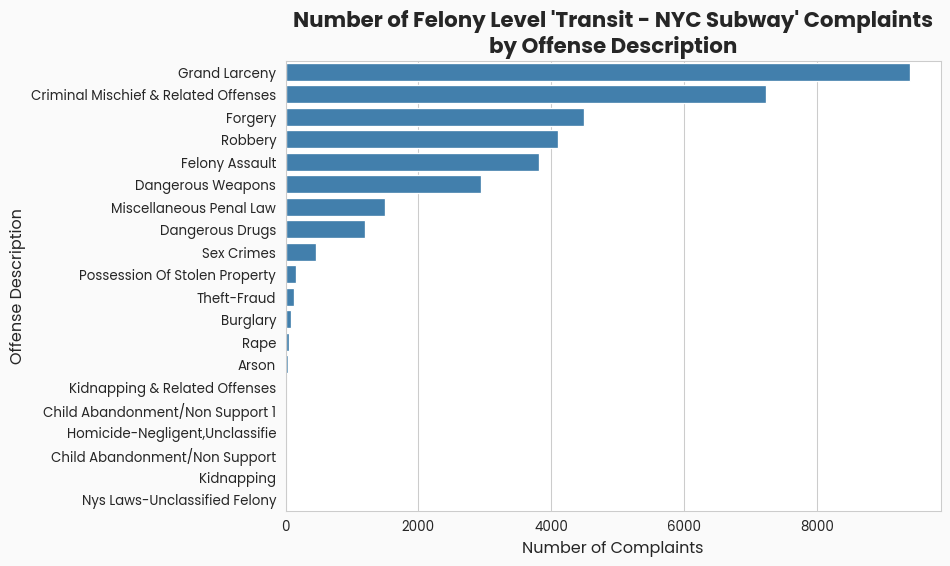

In [143]:
# plot the counts of offense descriptions for felony level offenses, sorted in descending order
plt.figure(figsize=(10, 6))
sns.barplot(data=offense_description_counts_by_law_cat['Felony'].sort_values(ascending=False).reset_index(name='count'), x='count', y='OFNS_DESC', color=colors[0])
plt.title("Number of Felony Level 'Transit - NYC Subway' Complaints\nby Offense Description", fontsize=16, fontweight='bold')
plt.xlabel('Number of Complaints', fontsize=12)
plt.ylabel('Offense Description', fontsize=12)
plt.tight_layout()
plt.show()

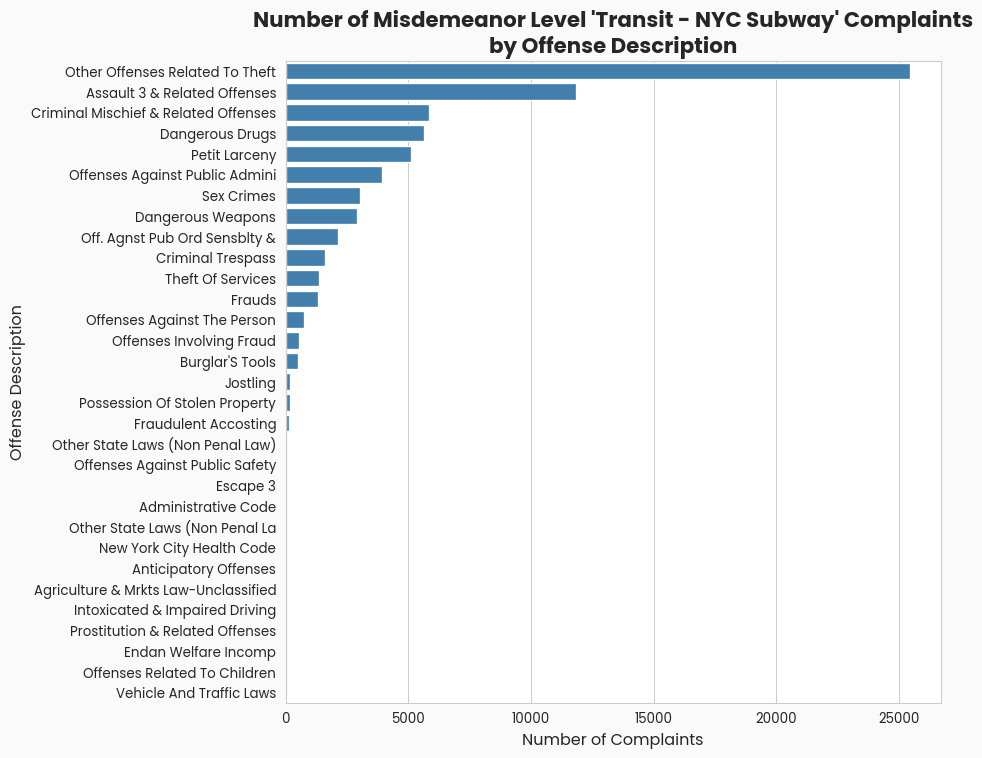

In [144]:
# plot the counts of offense descriptions for misdemeanor level offenses, sorted in descending order
plt.figure(figsize=(10, 8))
sns.barplot(data=offense_description_counts_by_law_cat['Misdemeanor'].sort_values(ascending=False).reset_index(name='count'), x='count', y='OFNS_DESC', color=colors[0])
plt.title("Number of Misdemeanor Level 'Transit - NYC Subway' Complaints\nby Offense Description", fontsize=16, fontweight='bold')
plt.xlabel('Number of Complaints', fontsize=12)
plt.ylabel('Offense Description', fontsize=12)
plt.tight_layout()
plt.show()

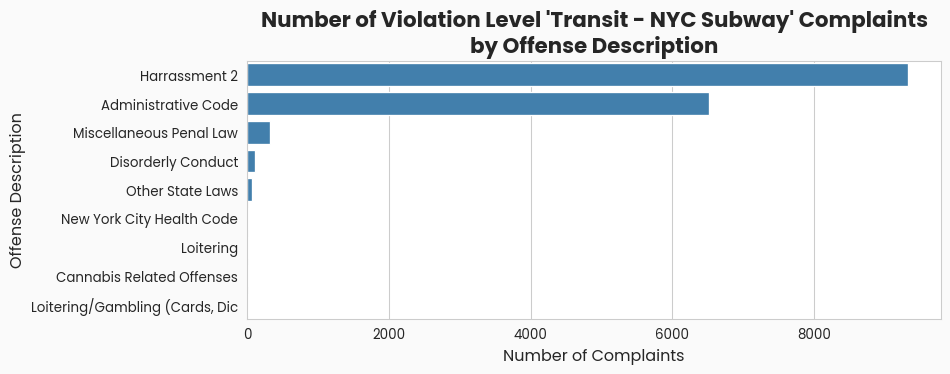

In [145]:
# plot the counts of offense descriptions for violation level offenses, sorted in descending order
plt.figure(figsize=(10, 4))
sns.barplot(data=offense_description_counts_by_law_cat['Violation'].sort_values(ascending=False).reset_index(name='count'), x='count', y='OFNS_DESC', color=colors[0])
plt.title("Number of Violation Level 'Transit - NYC Subway' Complaints\nby Offense Description", fontsize=16, fontweight='bold')
plt.xlabel('Number of Complaints', fontsize=12)
plt.ylabel('Offense Description', fontsize=12)
plt.tight_layout()
plt.show()

#### JURIS_DESC

In [146]:
transit_subway_complaints['JURIS_DESC'].value_counts()

JURIS_DESC
N.Y. TRANSIT POLICE    124582
N.Y. POLICE DEPT            7
Name: count, dtype: int64

## Appendix

### Yearly Complaint Counts

Counts of all complaints by year.

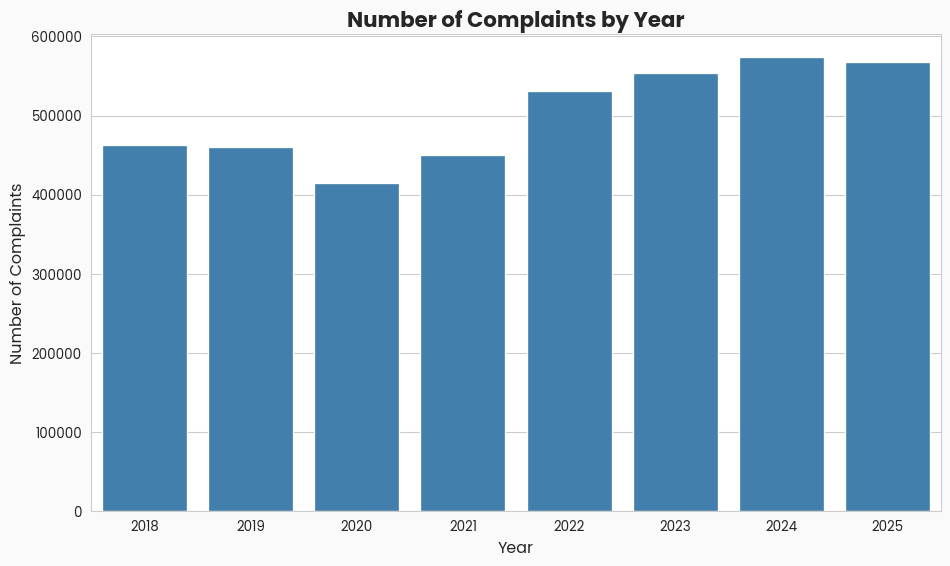

In [147]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df.groupby('CMPLNT_FR_YEAR').size().reset_index(name='count'), x='CMPLNT_FR_YEAR', y='count', color=colors[0])
plt.title("Number of Complaints by Year", fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Complaints', fontsize=12)
plt.tight_layout()
plt.show()

### Level of Offense

Distribution of all complaints by level of offense.

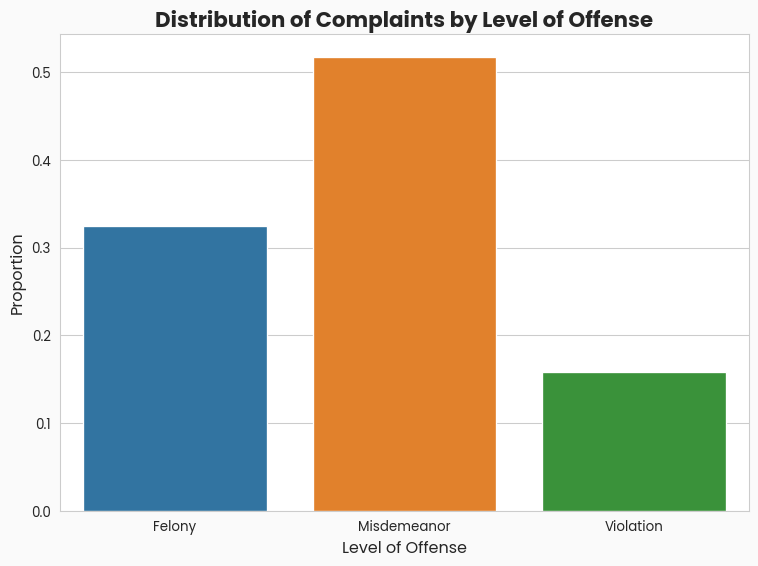

In [148]:
# Plot the distribution of LAW_CAT_CD
plt.figure(figsize=(8, 6))
ax = sns.countplot(data=df, x='LAW_CAT_CD', hue='LAW_CAT_CD', stat="proportion", width=0.8, dodge=False)
# Use large bolder font for title and axis labels
plt.title('Distribution of Complaints by Level of Offense', fontsize=16, fontweight="bold")
plt.xlabel('Level of Offense', fontsize=12, fontweight='regular')
plt.ylabel('Proportion', fontsize=12, fontweight='regular')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Premise

In [149]:
sorted(df['CMPLNT_FR_YEAR'].unique())

[np.int32(2018),
 np.int32(2019),
 np.int32(2020),
 np.int32(2021),
 np.int32(2022),
 np.int32(2023),
 np.int32(2024),
 np.int32(2025)]

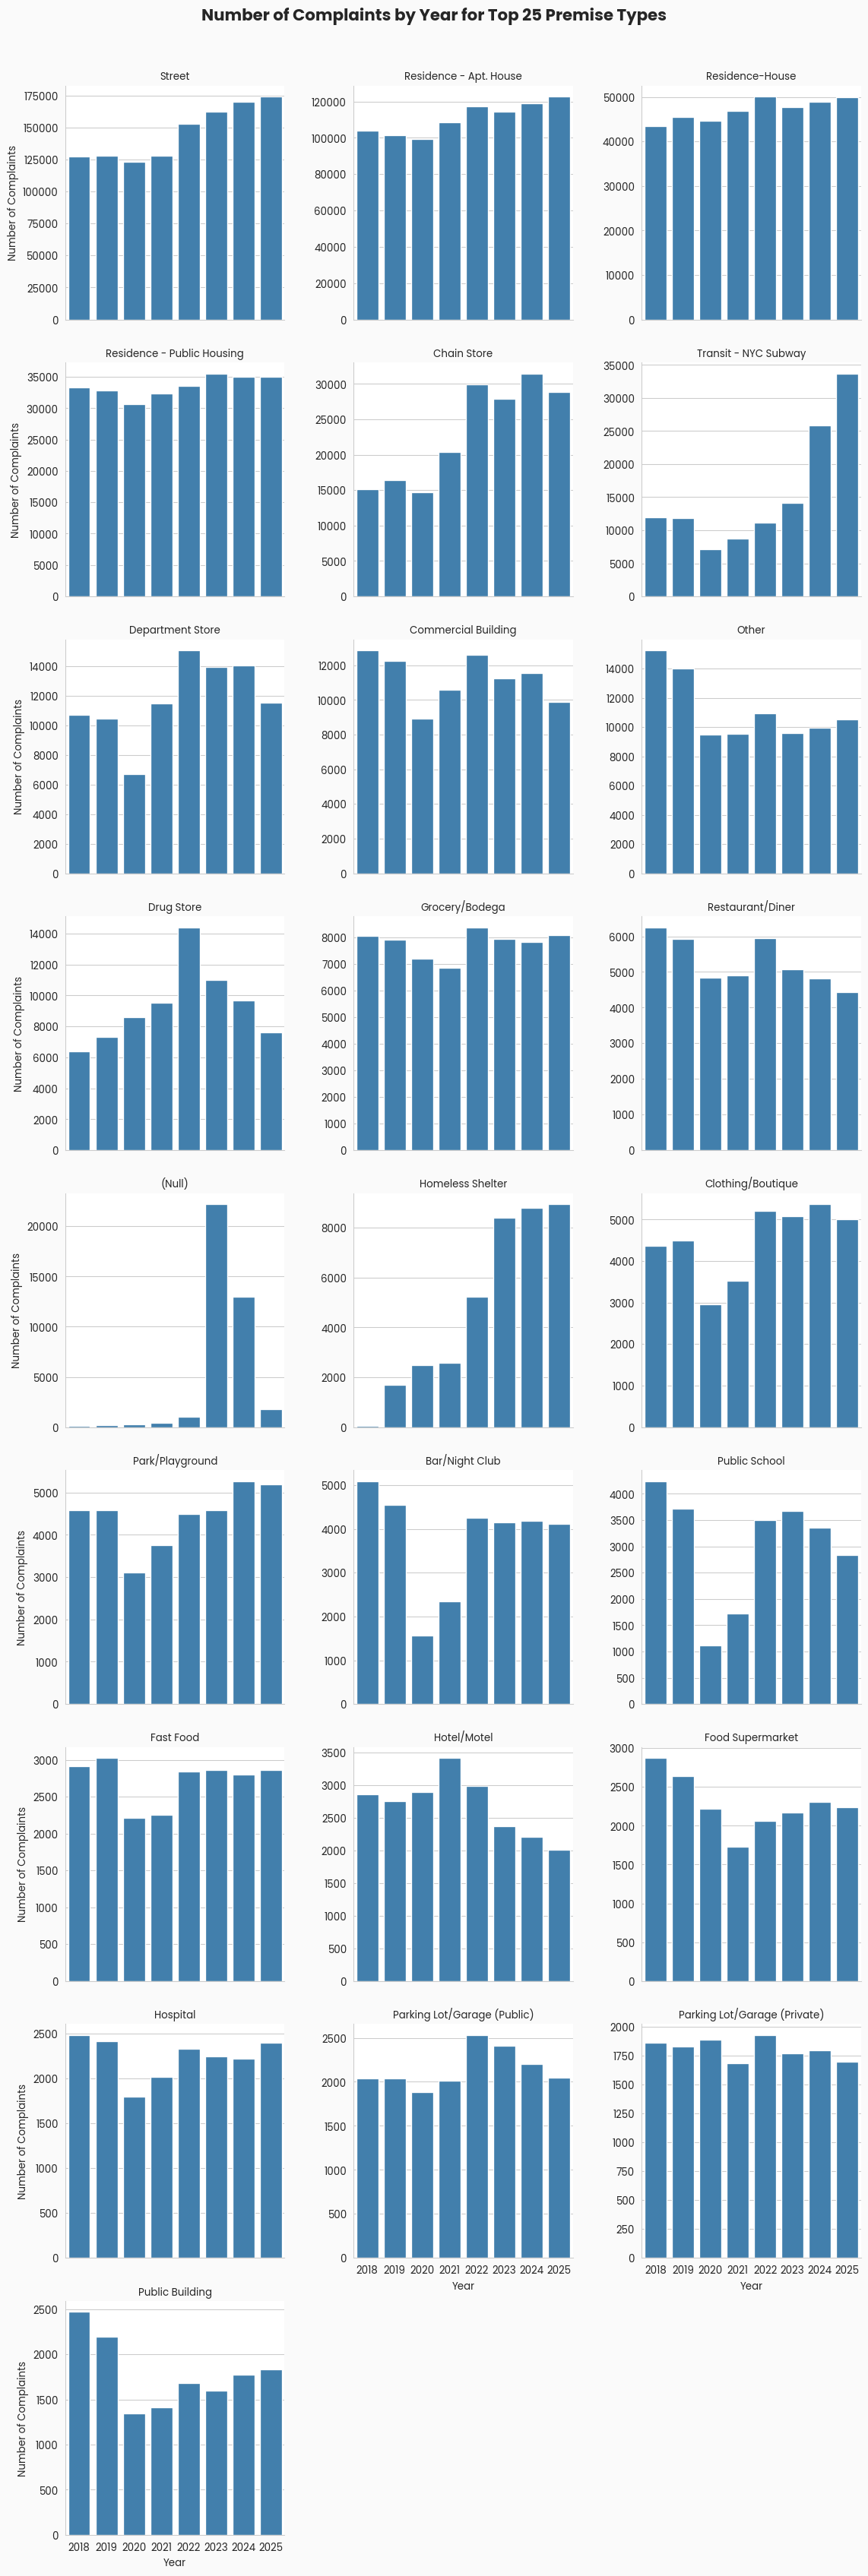

In [150]:
# plot a facetgrid of barplots showing the counts of complaints by year and PREM_TYP_DESC, order the facets alphabetically by PREM_TYP_DESC and only include the top 25 most common PREM_TYP_DESC values
top_25_prem_types = df['PREM_TYP_DESC'].value_counts().head(25).index
df_top_25_prem_types = df[df['PREM_TYP_DESC'].isin(top_25_prem_types)]
g = sns.FacetGrid(df_top_25_prem_types, col='PREM_TYP_DESC', col_wrap=3, height=4, sharey=False, col_order=top_25_prem_types)
g.map(sns.countplot, 'CMPLNT_FR_YEAR', order=sorted(df['CMPLNT_FR_YEAR'].unique()), color=colors[0])
g.set_titles(col_template="{col_name}")
g.set_axis_labels("Year", "Number of Complaints")
plt.subplots_adjust(top=0.95)
g.fig.suptitle('Number of Complaints by Year for Top 25 Premise Types', fontsize=16, fontweight='bold')     
plt.show()